## Focal Point

the original ipynb got really messy and I realized that:
- HTTP streaming every single video would take a VERY long time since each video requires a network round trip, and would have very little output.
- I can't download 108 thousand videos to my computer.
- I don't know what to do.


So I'm somewhat starting over! Using feature extraction instead, extracting features once and training a model based on the features, so that I can actually save it to my local machine.

Like a raw video might be 5 megabytes, but the feature vector would just be 512 floats or 2 KB. 108 thousand videos would therefore be ~200 megabytes.

In [1]:
pip install decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 75.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import os
from tqdm import tqdm
import io
import pandas as pd

import torch
import torchcodec
import torch.nn as nn
from torchvision.models.video import r3d_18, R3D_18_Weights
from torch.utils.data import IterableDataset, DataLoader, Dataset

from datasets import load_dataset
import decord

from huggingface_hub import HfFileSystem
from huggingface_hub import hf_hub_download
import random

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


--------------------

In [5]:
csv_path = hf_hub_download(
    repo_id = "ZahidYasinMittha/American-Sign-Language-Dataset",
    filename = "Aslense Dataset.csv",
    repo_type = "dataset"
)

Aslense%20Dataset.csv:   0%|          | 0.00/3.68M [00:00<?, ?B/s]

In [6]:
df = pd.read_csv(csv_path)
df.describe()

,word,videos
count,108618,108618
unique,2207,108617
top,erase,h_5.mp4
freq,160,2


In [7]:
df.head(5)

,word,videos
0,a,A.mp4
1,a,a_7.mp4
2,a,a_2.mp4
3,a,a_4.mp4
4,a,a_1.mp4


In [8]:
ds_debug = load_dataset("ZahidYasinMittha/American-Sign-Language-Dataset", streaming = True, split = "train")

for sample in ds_debug:
  print(type(sample["video"]))
  print(dir(sample["video"]))
  print(sample.keys())
  break

README.md:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/22 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

<class 'torchcodec.decoders._video_decoder.VideoDecoder'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_begin_stream_seconds', '_cpu_fallback', '_decoder', '_end_stream_seconds', '_get_key_frame_indices', '_getitem_int', '_getitem_slice', '_hf_encoded', '_num_frames', 'cpu_fallback', 'get_all_frames', 'get_frame_at', 'get_frame_played_at', 'get_frames_at', 'get_frames_in_range', 'get_frames_played_at', 'get_frames_played_in_range', 'metadata', 'stream_index']
dict_keys(['video'])


In [9]:
fs = HfFileSystem()
all_files = fs.glob("datasets/ZahidYasinMittha/American-Sign-Language-Dataset/part_*/*.mp4")
print(f"Total files found: {len(all_files)}")
print("Sample paths: ", all_files[:5])

HTTP Error 504 thrown while requesting GET https://huggingface.co/api/datasets/ZahidYasinMittha/American-Sign-Language-Dataset/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSndZWEowWHpndlpteHZkMlZ5WDNacFpHVnZYell1YlhBMElpd2lkSEpsWlY5dmFXUWlPaUkzWmprNU1UaGhaR1ZsWmpNNU5XVm1NbVprWlRjME1qUTNZV0l5TVdNellXWm1aRGRpT0RKbUluMD06OTQwMDA%3D
Retrying in 1s [Retry 1/5].


Total files found: 108616
Sample paths:  ['datasets/ZahidYasinMittha/American-Sign-Language-Dataset/part_1/000017451997373907346-LIBRARY.mp4', 'datasets/ZahidYasinMittha/American-Sign-Language-Dataset/part_1/0000197996356050556-CELERY.mp4', 'datasets/ZahidYasinMittha/American-Sign-Language-Dataset/part_1/000039681044643247176-PUSH.mp4', 'datasets/ZahidYasinMittha/American-Sign-Language-Dataset/part_1/0001523804663805528-PASSPORT.mp4', 'datasets/ZahidYasinMittha/American-Sign-Language-Dataset/part_1/00015575668519507424-GOVERNMENT.mp4']


In [10]:
class ASLStreamingDataset(IterableDataset):
  def __init__(self, word_to_idx, file_list, split_ratio = 0.8, split = "train", buffer_size = 200, num_frames = 16, frame_size = (112, 112)):
    super().__init__()
    self.word_to_idx = word_to_idx
    # self.split = split
    # self.buffer_size = buffer_size
    self.num_frames = num_frames
    self.frame_size = frame_size

    self.filename_to_word = {
        row["videos"].strip(): row["word"].strip()
        for _, row in df.iterrows()
    }

    labeled_files = [
        f for f in file_list
        if os.path.basename(f) in self.filename_to_word
    ]
    print(f"Files with labels found: {len(labeled_files)} / {len(file_list)}")

    labeled_files = sorted(labeled_files)
    random.seed(42) # random train/test split
    random.shuffle(labeled_files) # shuffle

    split_idx = int(len(labeled_files) * split_ratio)

    if split == "train":
      self.files = labeled_files[:split_idx]
    else:
      self.files = labeled_files[split_idx:]
    print(f"{split} split: {len(self.files)} files")

  def __iter__(self):
    fs = HfFileSystem()
    files = self.files.copy()
    random.shuffle(files)

    for hf_path in files:
      filename = os.path.basename(hf_path)
      word = self.filename_to_word.get(filename)

      if word is None or word not in self.word_to_idx:
        continue

      label_idx = self.word_to_idx[word]

      # read the file from hf directly
      try:
        with fs.open(hf_path, "rb") as f:
          video_bytes = f.read()

        tensor = self._preprocess(video_bytes)
        if tensor is None:
          continue

        yield tensor, torch.tensor(label_idx, dtype = torch.long)

      except Exception as e:
        print(f"Failed to load {filename}: {e}")
        continue


  def _preprocess(self, video_bytes): # this si a videoencoder object, not raw bytes
    try:
      import tempfile
      with tempfile.NamedTemporaryFile(suffix = ".mp4", delete = False) as tmp:
        tmp.write(video_bytes)
        tmp_path = tmp.name

      decoder = torchcodec.decoders.VideoDecoder(tmp_path)
      frame_batch = decoder.get_all_frames()
      frames = frame_batch.data
      os.unlink(tmp_path)

      if frames.shape[0] == 0:
        return None

      T = frames.shape[0]
      indices = torch.linspace(0, T - 1, self.num_frames).long()
      frames = frames[indices].float()

      H, W = self.frame_size
      frames = torch.nn.functional.interpolate(
          frames, size = (H, W), mode = "bilinear", align_corners = False
      )

      frames = frames / 255.0

      mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1)
      std = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1)
      frames = (frames - mean) / std

      return frames.permute(1, 0, 2, 3).contiguous()

    except Exception as e:
      print(f"Preprocess error: {e}")
      return None

I'm gonna just do 10 words because 50 words is going to take 120 minutes.

In [11]:
top_words = df["word"].value_counts().head(10).index.tolist() # a list of the 50 most common words

In [12]:
unique_words = sorted(df["word"].unique())
word_to_idx = {word: i for i, word in enumerate(top_words)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

num_classes = len(word_to_idx) # 50 classes
print(f"Number of classes: {num_classes}")

Number of classes: 10


----------------------------

In [13]:
class ASLClassifier(nn.Module):
  def __init__(self, num_classes, freeze_backbone = True):
    # we use the numbe of classes (num_classes) for the number of asl words (in this case, 2208)
    # the architecture of f3d_18 has a last layer that's trained on 400 kinetic's classes
    # but we'll change that last layer to train on 2208 asl words

    super().__init__()
    self.backbone = r3d_18(weights = R3D_18_Weights.DEFAULT) # r3d 18 weights default gives best available pretrained weights & downloads about 45 megabtes of websites from pytorch models

    if freeze_backbone:
      for param in self.backbone.parameters():
        param.requires_grad = False

    in_features = self.backbone.fc.in_features
    # original fc layer is backbone.fc = Linear(512, 400) but we need to replace the 400 with the number of clsses we have (2208)


    self.backbone.fc = nn.Sequential(
        nn.Dropout(p = 0.3),
        nn.Linear(in_features, num_classes)
    )

  def forward(self, x):
    return self.backbone(x)

  def unfreeze_backbone(self):
    for param in self.backbone.parameters():
      param.requires_grad = True
    print("Backbone unfrozen. All params are now trainable")

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ASLClassifier(num_classes=num_classes, freeze_backbone=True)
model = model.to(device)

Using device: cuda
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:02<00:00, 45.2MB/s]


------------------------

### Feature Extractor

In [15]:
feature_extractor = model.backbone

In [16]:
feature_extractor.fc = torch.nn.Identity() # remove fc layer so only 512-dim features, not class logits, get extracted

In [17]:
feature_extractor.eval()
feature_extractor = feature_extractor.to(device)

In [18]:
save_dir = "/content/drive/MyDrive/asl_features" # save to the specific drive folder
os.makedirs(save_dir, exist_ok = True)

In [19]:
target_words = set(word_to_idx.keys())

In [20]:
filename_to_word = {
    row["videos"].strip(): row["word"].strip()
    for _, row in df.iterrows()
    if row["word"].strip() in target_words
}

In [21]:
files_50 = [
    f for f in all_files
    if os.path.basename(f) in filename_to_word # filter all files to only 50 words
]

In [22]:
print(f"Files to process: {len(files_50)}")

Files to process: 1514


In [23]:
import tempfile

In [24]:
def preprocess_bytes(video_bytes, num_frames = 16, frame_size = (112, 112)):
  try:
    with tempfile.NamedTemporaryFile(suffix = ".mp4", delete = False) as tmp:
      tmp.write(video_bytes)
      tmp_path = tmp.name

    decoder = torchcodec.decoders.VideoDecoder(tmp_path)
    frame_batch = decoder.get_all_frames()
    frames = frame_batch.data.float() # (T, 3, H, W)
    os.unlink(tmp_path)

    if frames.shape[0] == 0:
      return None

    T = frames.shape[0]
    indices = torch.linspace(0, T - 1, num_frames).long()
    frames = frames[indices]

    H, W = frame_size
    frames = torch.nn.functional.interpolate(
        frames, size = (H, W), mode = "bilinear", align_corners = False
    )

    frames = frames / 255.0

    mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1)
    std = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1)
    frames = (frames - mean) / std

    return frames.permute(1, 0, 2, 3).contiguous() # (3, T, H, W)

  except Exception as e:
    print(f"Preprocess error: {e}")
    return None

In [25]:
failed = 0
saved = 0

In [26]:
with torch.no_grad():
  for hf_path in tqdm(files_50):
    filename = os.path.basename(hf_path)
    save_path = os.path.join(save_dir, filename.replace(".mp4", ".npy"))

    if os.path.exists(save_path):
      saved += 1
      continue

    try:
      # streaming
      with fs.open(hf_path, "rb") as f:
        video_bytes = f.read()

      tensor = preprocess_bytes(video_bytes) # existing preprocessing
      if tensor is None:
        failed += 1
        continue

      tensor = tensor.unsqueeze(0).to(device) # the tensor is (3, T, H, W) and add batch dim so now (1, 3, T, H, W)
      features = feature_extractor(tensor) # (1, 512)
      features = features.squeeze(0).cpu().numpy() # (512, )

      np.save(save_path, features)
      saved += 1

    except Exception as e:
      print(f"Failed {filename}: {e}")
      failed += 1

100%|██████████| 1514/1514 [00:00<00:00, 3623.16it/s]


In [27]:
print(f"Saved: {saved}, failed: {failed}")
print(f"Feature directory size: {sum(os.path.getsize(os.path.join(save_dir, f)) for f in os.listdir(save_dir)) / 1e6:.2f} megabytes")

Saved: 1514, failed: 0
Feature directory size: 3.29 megabytes


------------------------------------

### Train on a Classifier

In [28]:
class FeatureDataset(Dataset):
  def __init__(self, feature_dir, filename_to_word, word_to_idx, split = "train", split_ratio = 0.8):
    self.samples = []

    all_npy = [f for f in os.listdir(feature_dir) if f.endswith(".npy")]
    pairs = []
    for npy_file in all_npy:
      mp4_name = npy_file.replace(".npy", ".mp4")

      word = filename_to_word.get(mp4_name)
      if word and word in word_to_idx:
        pairs.append((
            os.path.join(feature_dir, npy_file),
            word_to_idx[word]
        ))

    pairs = sorted(pairs)
    random.seed(42)
    random.shuffle(pairs)
    split_idx = int(len(pairs) * split_ratio)

    self.samples = pairs[:split_idx] if split == "train" else pairs[split_idx:]
    print(f"{split}: {len(self.samples)} feature vectors")

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path, label = self.samples[idx]
    features = torch.from_numpy(np.load(path))
    return features, torch.tensor(label, dtype = torch.long)

In [50]:
class FeatureClassifier(nn.Module): # multilayer perceptrion -- simplest neural network architecture
  def __init__(self, num_classes, input_dim = 512): # 512 input numbers = flat list
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, 256), # 256 neurons computes a weighted sum of 512 inputs, plus bias
        nn.ReLU(),  # simple relu activation layer (replace all negative values with 0)
        nn.Dropout(0.3), # randomly zeroes 30% of the 256 values to prevent overfitting
        nn.Linear(256, num_classes) # final layer maps one score per class
    )

  def forward(self, x):
    return self.net(x)

In [66]:
# class FeatureClassifier(nn.Module): # multilayer perceptrion -- simplest neural network architecture
#   def __init__(self, num_classes, input_dim = 512): # 512 input numbers = flat list
#     super().__init__()
#     self.net = nn.Sequential(
#         nn.Linear(input_dim, 128), # 256 neurons computes a weighted sum of 512 inputs, plus bias
#         nn.BatchNorm1d(128),
#         nn.ReLU(),  # simple relu activation layer (replace all negative values with 0)
#         nn.Dropout(0.5), # randomly zeroes 30% of the 256 values to prevent overfitting
#         nn.Linear(128, num_classes) # final layer maps one score per class
#     )

#   def forward(self, x):
#     return self.net(x)

^^ i just tested a batch normalization fix but it lowkey didnt work because accuracy still stabilized around 20% and overfitting was still high.

therefore, just use the previous one. ignore this one because it didn't do much

--

### 6.30.2026, 1:00 PM notes:

Model is currently struggling with...
- Overfitting (very high loss)
- Low validation accuracy

In [59]:
# i want to test if this is a data problem or a model problem so
# are the features themselves not separable? would a logistic regression struggle here?
# if logistic regression strugles then the issue is the features

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [61]:
X = np.array([np.load(p) for p, _ in train_features.samples])
y = np.array([l for _, l in train_features.samples])

In [62]:
X_test = np.array([np.load(p) for p, _ in test_features.samples])
y_test = np.array([l for _, l in test_features.samples])

In [63]:
clf = LogisticRegression(max_iter = 2000)
clf.fit(X, y)

LogisticRegression(max_iter=2000)

In [64]:
log_val_acc = clf.score(X_test, y_test) * 100

In [65]:
print(f"Logistic regression validation accuracy: {log_val_acc}%")

Logistic regression validation accuracy: 22.112211221122113%


So basically logistic regression struggles with the data.

I have to figure out what to do to tweak the features instead of the neural network architecture.

--

In [67]:
train_features = FeatureDataset(save_dir, filename_to_word, word_to_idx, split = "train")
test_features = FeatureDataset(save_dir, filename_to_word, word_to_idx, split = "test")
# no need to stream from HTTP this time because they're just loaded from the disk instantly

train: 1211 feature vectors
test: 303 feature vectors


In [68]:
train_features_loader = DataLoader(train_features, batch_size = 64, shuffle = True, num_workers = 2)
test_features_loader = DataLoader(test_features, batch_size = 64, shuffle = False, num_workers = 2)
# ^ reading the npy files

In [69]:
classifier = FeatureClassifier(num_classes = num_classes).to(device)
optimizer = torch.optim.AdamW(classifier.parameters(), lr = 1e-3) # adam optimizer, learning rate of 1e-3
criterion = nn.CrossEntropyLoss(label_smoothing = 0.1)

In [70]:
train_accs = []
val_accs = []
train_losses = []
val_losses = []

In [71]:
for epoch in range(1, 51): # (1, 21) for example means 20 epochs.
  classifier.train()
  correct, total, running_loss = 0, 0, 0.0

  for features, labels in train_features_loader:
    features, labels = features.to(device), labels.to(device)
    optimizer.zero_grad()

    logits = classifier(features)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    correct += (logits.argmax(1) == labels).sum().item()
    total += labels.size(0)

  classifier.eval()
  val_correct, val_total, val_loss = 0, 0, 0.0 # evaluation accuracy
  with torch.no_grad():
    for features, labels in test_features_loader:
      features, labels = features.to(device), labels.to(device)

      logits = classifier(features)
      val_loss += criterion(logits, labels).item()

      preds = logits.argmax(1)
      val_correct += (preds == labels).sum().item()
      val_total += labels.size(0)

  print(
      f"\nEpoch {epoch:02d}"
      f"\nLoss: {running_loss/len(train_features_loader):.4f}"
      f"\nTrain: {correct/total * 100:.1f}%"
      f"\nValidation: {val_correct / val_total * 100:.1f}%"
  )

  train_accs.append(correct / total * 100)
  val_accs.append(val_correct / val_total * 100)
  train_losses.append(running_loss / len(train_features_loader))
  val_losses.append(val_loss / len(test_features_loader))


Epoch 01
Loss: 2.3860
Train: 12.4%
Validation: 13.2%

Epoch 02
Loss: 2.1544
Train: 24.9%
Validation: 16.5%

Epoch 03
Loss: 2.0213
Train: 32.7%
Validation: 15.2%

Epoch 04
Loss: 1.9466
Train: 37.9%
Validation: 15.2%

Epoch 05
Loss: 1.8831
Train: 39.8%
Validation: 15.2%

Epoch 06
Loss: 1.8156
Train: 44.0%
Validation: 18.5%

Epoch 07
Loss: 1.7532
Train: 47.3%
Validation: 22.1%

Epoch 08
Loss: 1.6694
Train: 51.5%
Validation: 20.1%

Epoch 09
Loss: 1.5981
Train: 56.5%
Validation: 20.8%

Epoch 10
Loss: 1.5524
Train: 57.6%
Validation: 21.5%

Epoch 11
Loss: 1.4980
Train: 59.0%
Validation: 22.1%

Epoch 12
Loss: 1.4545
Train: 60.1%
Validation: 22.1%

Epoch 13
Loss: 1.4058
Train: 63.0%
Validation: 21.8%

Epoch 14
Loss: 1.3897
Train: 62.4%
Validation: 20.1%

Epoch 15
Loss: 1.3274
Train: 66.1%
Validation: 24.1%

Epoch 16
Loss: 1.2911
Train: 67.1%
Validation: 22.8%

Epoch 17
Loss: 1.2636
Train: 70.2%
Validation: 23.8%

Epoch 18
Loss: 1.2191
Train: 72.0%
Validation: 24.1%

Epoch 19
Loss: 1.2120
Train

### Plotting Results

In [56]:
import matplotlib.pyplot as plt

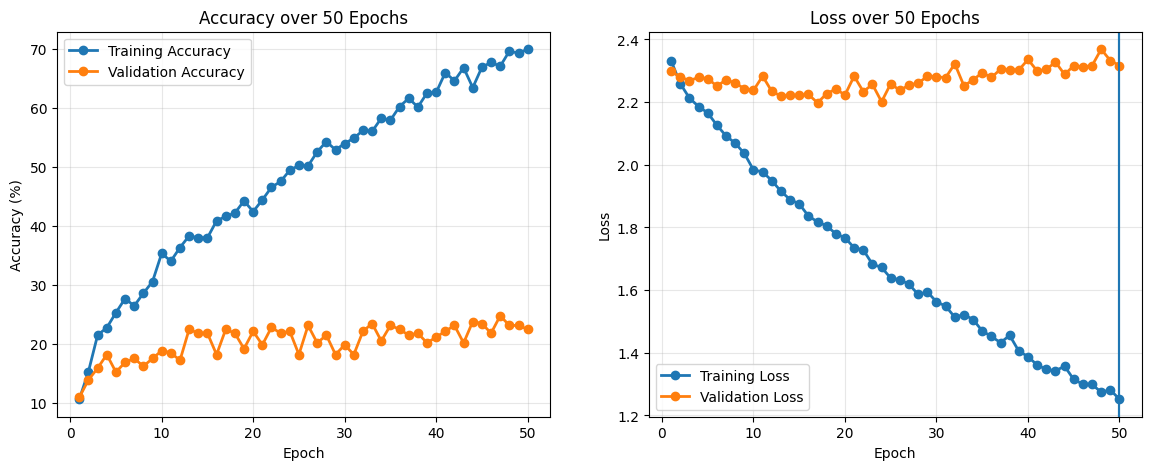

In [57]:
num_epochs = range(1, len(train_accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.plot(num_epochs, train_accs, label = "Training Accuracy", marker = "o", linewidth = 2)
ax1.plot(num_epochs, val_accs, label = "Validation Accuracy", marker = "o", linewidth = 2)

ax1.set_title("Accuracy over 50 Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")

ax1.legend()
ax1.grid(True, alpha = 0.3)

plt.axvline(x = 50)

# loss
ax2.plot(num_epochs, train_losses, label = "Training Loss", marker = "o", linewidth = 2)
ax2.plot(num_epochs, val_losses, label = "Validation Loss", marker = "o", linewidth = 2)

ax2.set_title("Loss over 50 Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")

ax2.legend()
ax2.grid(True, alpha = 0.3)

# adfhasdfoihnado something something vertical line to mark progress
plt.axvline(x = 50)

plt.show()